# Example: hydrogen shock tube

This notebook evaluates a hydrogen–oxygen kinetic model against shock-tube
ignition-delay measurements for a dilute H₂/O₂/Ar mixture, then compares the
*simulated* ignition delays with the *experimental* values.

The experimental data, dataset list, and species-key file live in the
`examples/h2o2-shocktube` directory of the repository
([browse on GitHub](https://github.com/pr-omethe-us/PyTeCK/tree/master/examples/h2o2-shocktube)).
The kinetic model, `h2o2.yaml`, ships with Cantera, so no local model file is
needed.

## Run the evaluation

The [evaluate_model](eval_model.rst) function reads the dataset, simulates
every datapoint, detects each ignition delay, and returns a dictionary
summarizing how well the model reproduces the measurements.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pyteck.eval_model import evaluate_model
from pyteck.utils import units

example_dir = Path("../examples/h2o2-shocktube").resolve()

In [2]:
output = evaluate_model(
    model_name="h2o2.yaml",
    spec_keys_file=str(example_dir / "spec_keys.yaml"),
    dataset_file=str(example_dir / "dataset_file.txt"),
    data_path=str(example_dir / "data"),
    model_path="",
    results_path="results",
)

print(f"average error function:     {output['average error function']:.3f}")
print(f"average deviation function: {output['average deviation function']:.3f}")

Standard deviation of 0.02 too low, using 0.10


Done with case  H2O2Ar-shocktube-example_1
Done with case  H2O2Ar-shocktube-example_0
Done with case  H2O2Ar-shocktube-example_4
Done with case  H2O2Ar-shocktube-example_2
Done with case  H2O2Ar-shocktube-example_3


average error function:     58.741
average deviation function: 7.633


## Compare experimental and simulated ignition delays

Pull the temperature and the experimental and simulated ignition delay out of
the results for each datapoint. The values are stored as strings with units,
so we parse them with PyTeCK's `units` registry.

In [ ]:
datapoints = output["datasets"][0]["datapoints"]

temperature = np.array([units.Quantity(dp["temperature"]).to("K").magnitude for dp in datapoints])
ignition_delay_experiment = np.array(
    [units.Quantity(dp["experimental ignition delay"]).to("us").magnitude for dp in datapoints]
)
ignition_delay_simulation = np.array(
    [units.Quantity(dp["simulated ignition delay"]).to("us").magnitude for dp in datapoints]
)

# sort by temperature so the simulated points join up smoothly
# (this is not really necessary for a pure scatterplot)
order = np.argsort(temperature)
temperature = temperature[order]
ignition_delay_experiment = ignition_delay_experiment[order]
ignition_delay_simulation = ignition_delay_simulation[order]

Plot the ignition delay (log scale) against 1000/T, the usual Arrhenius-style
presentation for ignition-delay data.

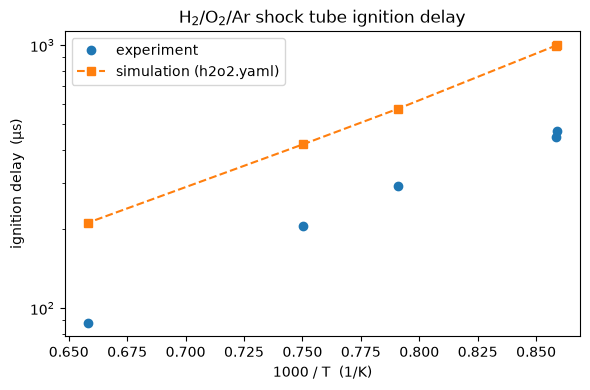

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.semilogy(1000.0 / temperature, ignition_delay_experiment, "o", label="experiment")
ax.semilogy(1000.0 / temperature, ignition_delay_simulation, "s--", label="simulation (h2o2.yaml)")

ax.set_xlabel("1000 / T  (1/K)")
ax.set_ylabel("ignition delay  (µs)")
ax.set_title("H$_2$/O$_2$/Ar shock tube ignition delay")
ax.legend()
fig.tight_layout()